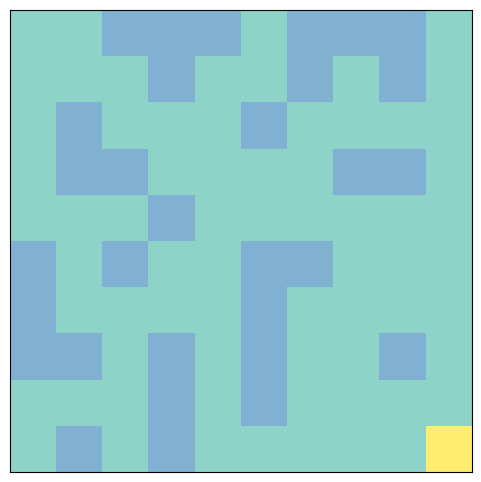

🎉 Congratulations! You reached the goal!
Shortest path length (BFS): 18 steps


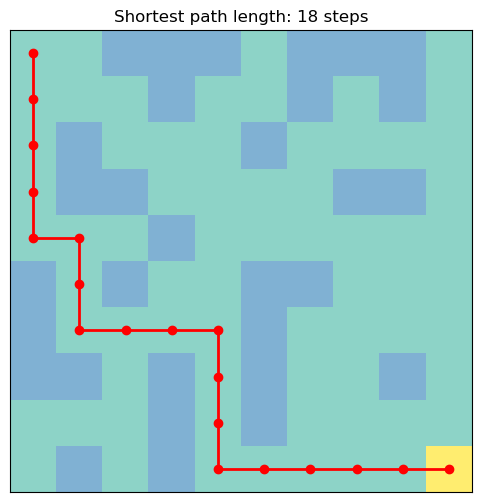

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import deque
from IPython.display import clear_output

# Maze settings
ROWS, COLS = 10, 10

# BFS function to find shortest path
def bfs_shortest_path(maze, start, goal):
    queue = deque([start])
    visited = {tuple(start): None}
    directions = [(0,1),(1,0),(0,-1),(-1,0)]  # down, right, up, left
    
    while queue:
        current = queue.popleft()
        if current == goal:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = visited[tuple(current)]
            path.reverse()
            return path
        for dx, dy in directions:
            nx, ny = current[0]+dx, current[1]+dy
            if 0 <= nx < COLS and 0 <= ny < ROWS and maze[ny,nx] == 0 and (nx, ny) not in visited:
                queue.append([nx, ny])
                visited[(nx, ny)] = current
    return None

# Generate a maze with guaranteed solvable path
def generate_maze(rows, cols):
    while True:
        maze = np.random.choice([0,1], size=(rows, cols), p=[0.7,0.3])
        maze[0,0] = 0
        maze[rows-1, cols-1] = 0
        if bfs_shortest_path(maze, [0,0], [cols-1, rows-1]) is not None:
            return maze

# Display maze with optional path
def show_maze(maze, player_pos=None, path=None):
    display_maze = maze.copy()
    if player_pos:
        display_maze[player_pos[1], player_pos[0]] = 2  # Player
    display_maze[ROWS-1, COLS-1] = 3  # Goal
    plt.figure(figsize=(6,6))
    plt.imshow(display_maze, cmap='Set3')
    plt.xticks([]); plt.yticks([])
    
    # Draw path if provided
    if path:
        px, py = zip(*path)
        plt.plot(px, py, color='red', linewidth=2, marker='o')
        plt.title(f"Shortest path length: {len(path)-1} steps")
    plt.show()

# Player start
maze = generate_maze(ROWS, COLS)
player_pos = [0,0]
goal = [COLS-1, ROWS-1]
moves = {'w':(0,-1), 's':(0,1), 'a':(-1,0), 'd':(1,0)}

# Game loop
show_maze(maze)
while player_pos != goal:
    move = input("Move (w=up, s=down, a=left, d=right) or 'h' for AI hint: ").lower()
    
    if move == 'h':
        path = bfs_shortest_path(maze, player_pos, goal)
        if path:
            print(f"AI Hint: Next step -> {path[1]}")
        else:
            print("No path exists!")
        continue

    if move in moves:
        dx, dy = moves[move]
        new_x = player_pos[0] + dx
        new_y = player_pos[1] + dy
        if 0 <= new_x < COLS and 0 <= new_y < ROWS and maze[new_y,new_x]==0:
            player_pos = [new_x, new_y]

    clear_output(wait=True)
    show_maze(maze, player_pos)

print("🎉 Congratulations! You reached the goal!")

# After game ends, show shortest path length and diagram
shortest_path = bfs_shortest_path(maze, [0,0], goal)
if shortest_path:
    print(f"Shortest path length (BFS): {len(shortest_path)-1} steps")
    show_maze(maze, path=shortest_path)